## Manual implementation of Metropolis - Hastings algorithm

In [78]:
import numpy as np
import sys
sys.path.append(r'C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks')
from Utilities import plot_settings
import matplotlib.pyplot as plt

Generate Data (Homoscedastic Gaussian Distribution)

In [358]:
np.random.seed(42)
N = int(1e5)
scales = np.random.uniform(0.2, 1.0, size=N)
data = np.random.normal(loc=3.0, scale=scales, size=N) 

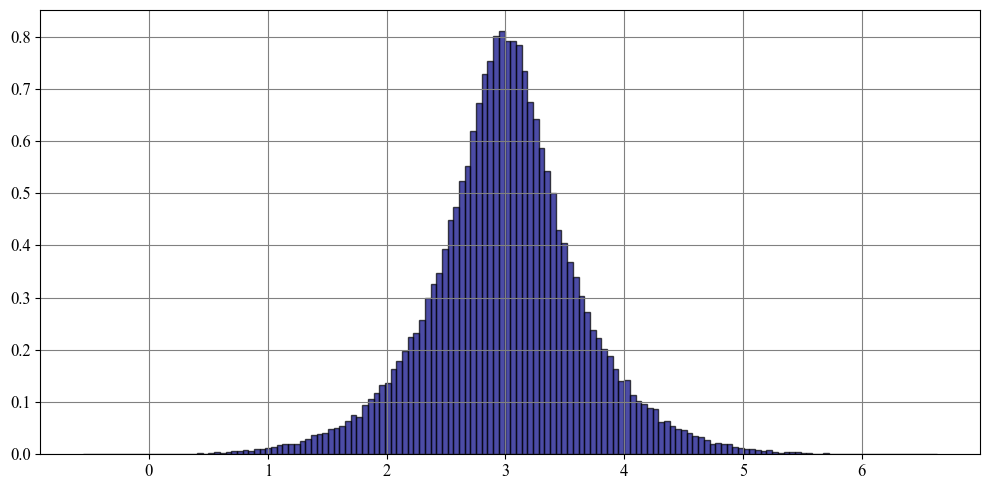

In [359]:
plt.hist(data, bins='scott', density=True, alpha=0.7, color='navy', label='Data Histogram', histtype='barstacked', edgecolor='black');

### Basic Metropolis - Hastings

In [360]:
def MetropolisHastings(data, log_posterior, kernel='gaussian', n_samples=10000, step=[0.1, 0.1], init_sample=None):
    if kernel not in ['gaussian', 'uniform']:
        raise ValueError("Kernel must be 'gaussian' or 'uniform'")

    step = np.array(step)
    dim = 2

    if init_sample is None:
        current_sample = np.array([np.random.normal(0, 1), np.random.uniform(0.5, 2.0)])
    else:
        current_sample = np.array(init_sample)

    samples = []
    current_log_post = log_posterior(current_sample, data)

    for _ in range(n_samples):
        if kernel == 'gaussian':
            proposed_sample = np.random.normal(current_sample, step)
        else:
            proposed_sample = np.random.uniform(current_sample - step, current_sample + step)

        proposed_log_post = log_posterior(proposed_sample, data)
        log_acceptance_ratio = proposed_log_post - current_log_post

        if np.log(np.random.rand()) < log_acceptance_ratio:
            current_sample = proposed_sample
            current_log_post = proposed_log_post

        samples.append(current_sample)

    return np.array(samples)


In [361]:
def log_likelihood(sample, data):
    mu, sigma = sample
    if sigma <= 0:
        return -np.inf  # Invalid: log-likelihood undefined for σ ≤ 0
    n = len(data)
    residual = data - mu
    return -0.5 * np.sum(residual ** 2) / sigma**2 - n * np.log(np.sqrt(2 * np.pi) * sigma)

def log_prior(sample):
    mu, sigma = sample
    if -10 < mu < 10 and 0.01 < sigma < 10:
        return 0.0
    return -np.inf

def log_posterior(sample, data):
    return log_prior(sample) + log_likelihood(sample, data)

In [365]:
# Run MCMC
samples = MetropolisHastings(data, log_posterior, step=[0.005, 0.005], init_sample=[1.0, 1.0])

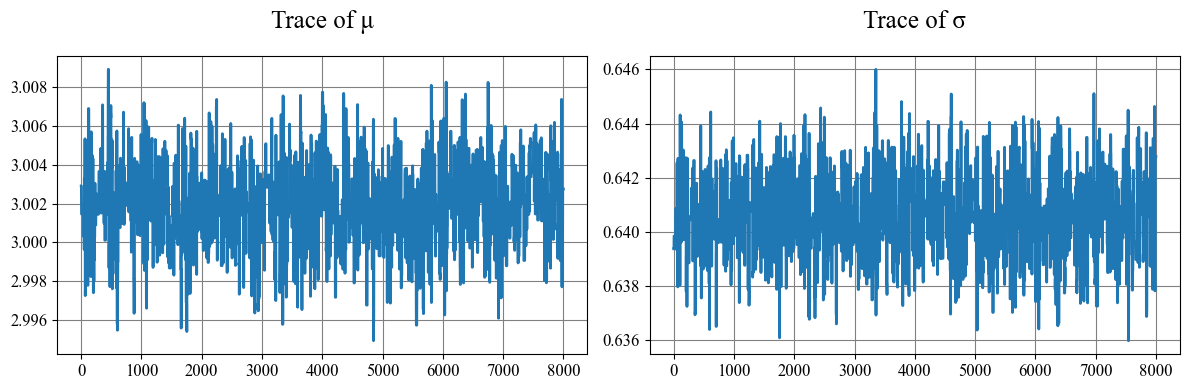

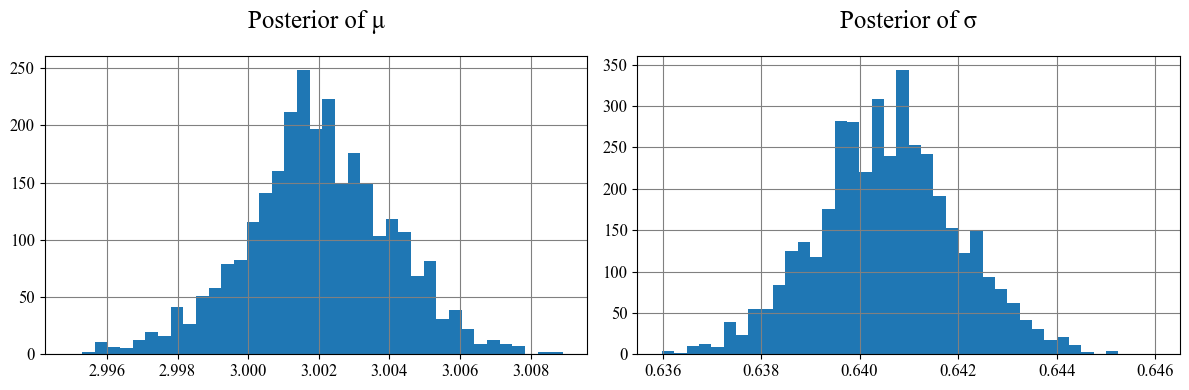

In [367]:
# Extract parameters
mu_samples = samples[:, 0][2000:]
sigma_samples = samples[:, 1][2000:]

# Plot traces
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mu_samples)
plt.title("Trace of μ")

plt.subplot(1, 2, 2)
plt.plot(sigma_samples)
plt.title("Trace of σ")

# Plot posterior histograms
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(mu_samples, bins='scott', density=True)
plt.title("Posterior of μ")

plt.subplot(1, 2, 2)
plt.hist(sigma_samples, bins='scott', density=True)
plt.title("Posterior of σ")
plt.show()


Adaptive Metropolis with PCA

In [368]:
from sklearn.decomposition import PCA
from tqdm import tqdm

In [369]:
def MetropolisHastingsPCA(data, log_posterior, kernel='gaussian', n_samples=10000,
                          step=[0.1, 0.1], init_sample=None, PCA_step=100, PCA_window=500,
                          PCA_enhanced=True):
    if kernel not in ['gaussian', 'uniform']:
        raise ValueError("Kernel must be 'gaussian' or 'uniform'")
    
    step = np.array(step)
    dim = len(step)

    if init_sample is None:
        # sensible starting point within prior
        current_sample = np.array([0.0, 1.0])
    else:
        current_sample = np.array(init_sample)

    samples = []
    recent_samples = []
    current_log_post = log_posterior(current_sample, data)

    pca = None
    transformation_matrix = np.eye(dim)
    
    if PCA_enhanced:    

        for i in tqdm(range(n_samples)):
            if kernel == 'gaussian':
                noise = np.random.normal(0, step, size=dim)
            else:
                noise = np.random.uniform(-step, step, size=dim)

            # transform noise by PCA if available
            if pca is not None:
                noise = transformation_matrix @ noise

            proposed_sample = current_sample + noise

            proposed_log_post = log_posterior(proposed_sample, data)

            log_acceptance_ratio = proposed_log_post - current_log_post

            if np.log(np.random.rand()) < log_acceptance_ratio:
                current_sample = proposed_sample
                current_log_post = proposed_log_post

            samples.append(current_sample)
            recent_samples.append(current_sample)
                
            if (i + 1) % PCA_step == 0 and len(recent_samples) >= dim:
                window_samples = np.array(recent_samples[-PCA_window:])
                if np.all(np.std(window_samples, axis=0) > 1e-8):
                    pca = PCA(n_components=dim)
                    pca.fit(window_samples)
                    transformation_matrix = pca.components_.T * np.sqrt(pca.explained_variance_)
                else:
                    # skip PCA update this time
                    pass
        return np.array(samples)
    else:
        return MetropolisHastings(data, log_posterior, kernel=kernel, n_samples=n_samples,
                             step=step, init_sample=init_sample)


In [375]:
samples = MetropolisHastingsPCA(
    data=data,
    log_posterior=log_posterior,
    kernel='gaussian',
    n_samples=50000,
    step=[0.05, 0.05],
    init_sample=[0.0, 1.0],
    PCA_step=200,
    PCA_window=500,
    PCA_enhanced=True
)

100%|██████████| 50000/50000 [00:19<00:00, 2578.96it/s]


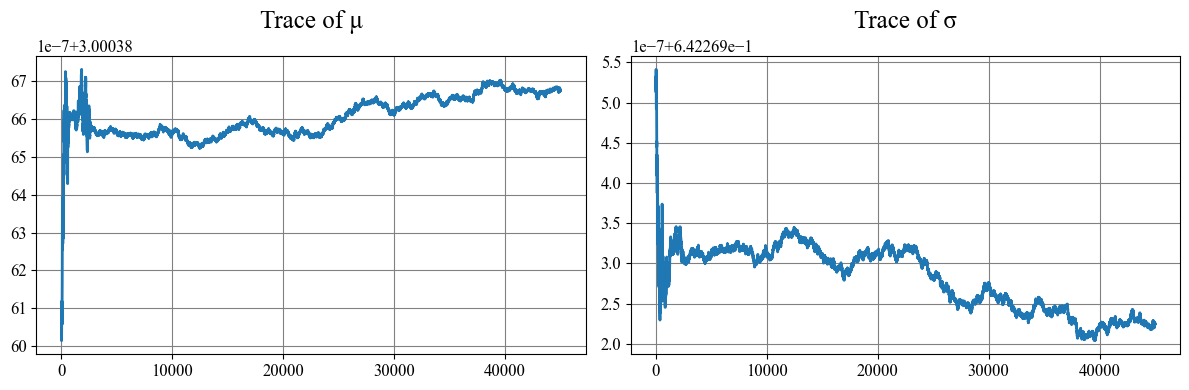

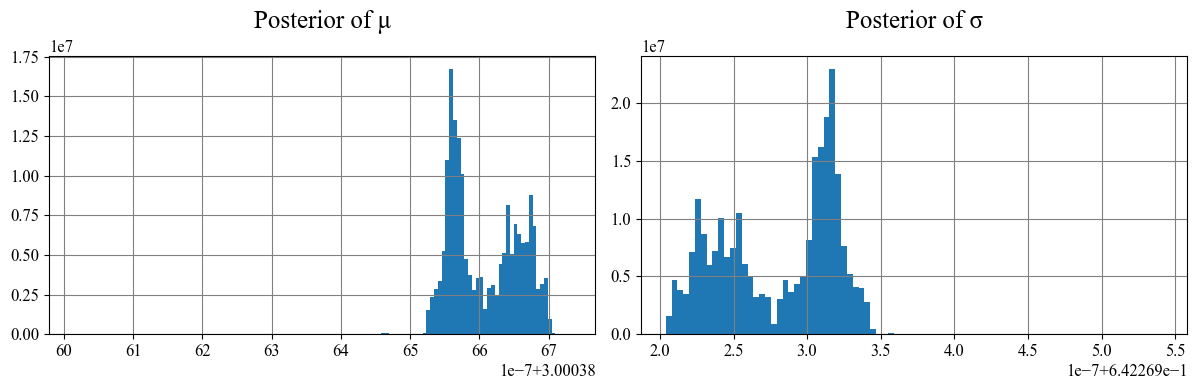

In [376]:
# Extract parameters
mu_samples = samples[:, 0][5000:]
sigma_samples = samples[:, 1][5000:]

# Plot traces
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mu_samples)
plt.title("Trace of μ")

plt.subplot(1, 2, 2)
plt.plot(sigma_samples)
plt.title("Trace of σ")

# Plot posterior histograms
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(mu_samples, bins='scott', density=True)
plt.title("Posterior of μ")

plt.subplot(1, 2, 2)
plt.hist(sigma_samples, bins='scott', density=True)
plt.title("Posterior of σ")
plt.show()


More challenging Data Distribution

In [377]:
mix_probs = np.random.rand(N)
scales1 = np.random.uniform(0.2, 1.0, size=N)
scales2 = np.random.uniform(0.5, 2.0, size=N)

# Generate base data from mixture
data = np.where(
    mix_probs < 0.7,
    np.random.normal(loc=3.0, scale=scales1),
    np.random.normal(loc=5.0, scale=scales2)
)

# Add heteroscedastic noise: noise scale depends on data value
noise_scales = 0.1 + 0.5 * np.abs(data - 4.0) / 2.0
data += np.random.normal(0, noise_scales)

# Inject outliers: 1% of data replaced by large noise
outlier_mask = np.random.rand(N) < 0.01
data[outlier_mask] += np.random.normal(0, 10, size=outlier_mask.sum())

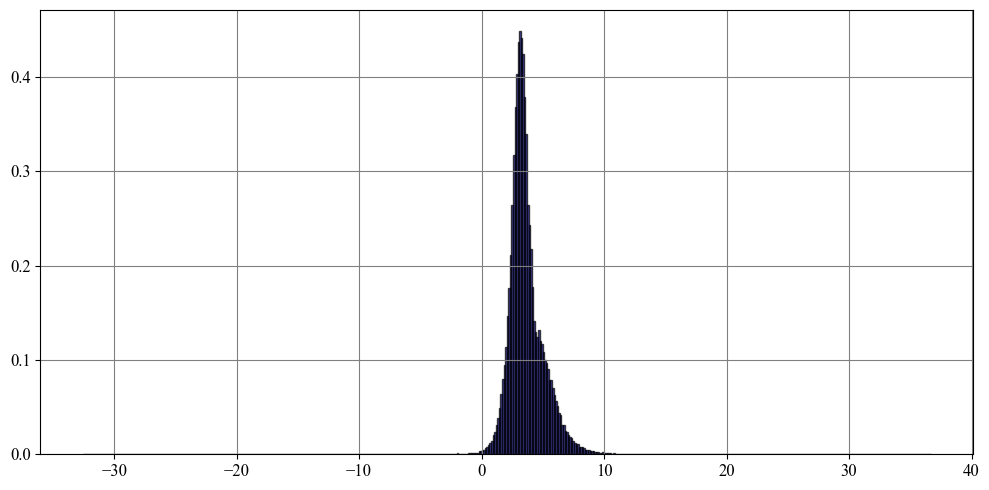

In [378]:
plt.hist(data, bins='scott', density=True, alpha=0.7, color='navy', label='Data Histogram', histtype='barstacked', edgecolor='black');

In [381]:
samples = MetropolisHastingsPCA(
    data=data,
    log_posterior=log_posterior,
    kernel='gaussian',
    n_samples=50000,
    step=[0.5, 0.5],
    init_sample=[0.0, 1.0],
    PCA_step=200,
    PCA_window=500,
    PCA_enhanced=True
)

100%|██████████| 50000/50000 [00:21<00:00, 2317.61it/s]


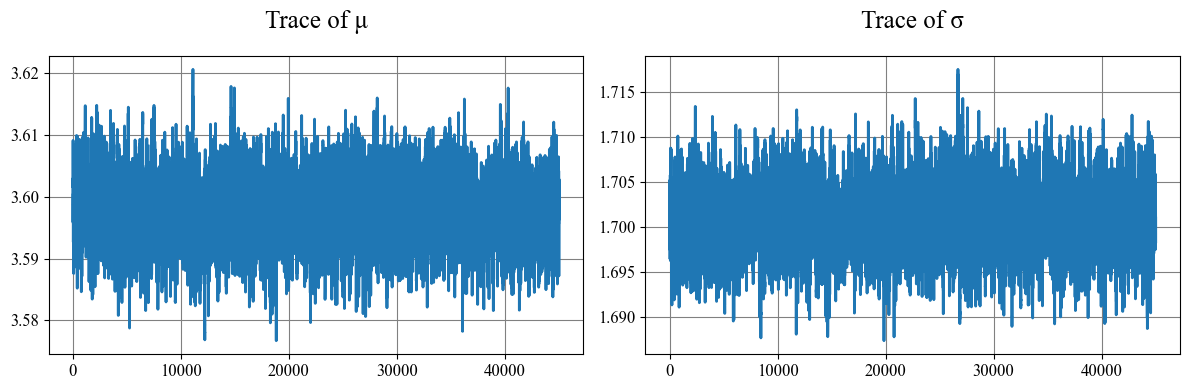

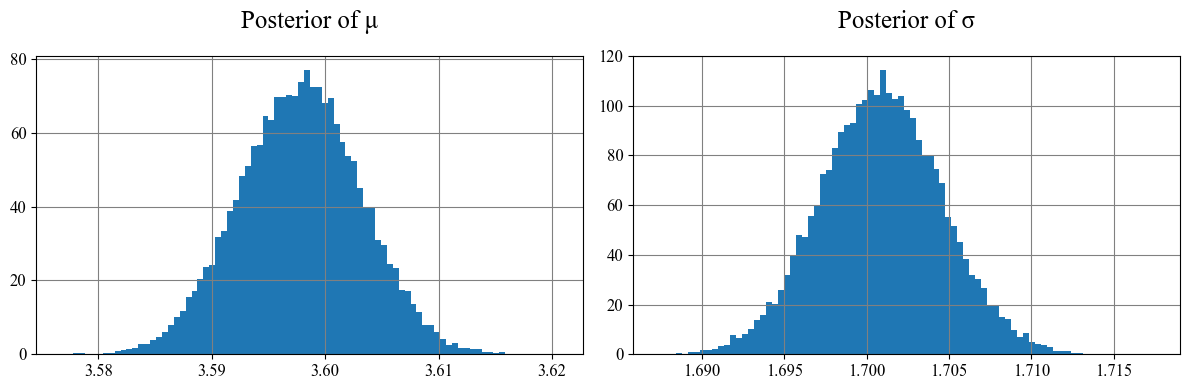

In [382]:
# Extract parameters
mu_samples = samples[:, 0][5000:]
sigma_samples = samples[:, 1][5000:]

# Plot traces
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mu_samples)
plt.title("Trace of μ")

plt.subplot(1, 2, 2)
plt.plot(sigma_samples)
plt.title("Trace of σ")

# Plot posterior histograms
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(mu_samples, bins='scott', density=True)
plt.title("Posterior of μ")

plt.subplot(1, 2, 2)
plt.hist(sigma_samples, bins='scott', density=True)
plt.title("Posterior of σ")
plt.show()

In [383]:
def MetropolisHastingsPCA_multiwalkers(data, log_posterior, n_walkers=10, kernel='gaussian', n_samples=10000,
                                       step=[0.1, 0.1], init_samples=None, PCA_step=100, PCA_window=500,
                                       PCA_enhanced=True):
    step = np.array(step)
    dim = len(step)

    if init_samples is None:
        # Initialize walkers around some sensible point
        init_samples = np.array([np.array([0.0, 1.0]) + np.random.normal(0, 0.01, size=dim) for _ in range(n_walkers)])
    else:
        init_samples = np.array(init_samples)
        if init_samples.shape != (n_walkers, dim):
            raise ValueError(f"init_samples must have shape ({n_walkers}, {dim})")

    samples = np.zeros((n_walkers, n_samples, dim))
    recent_samples = [[] for _ in range(n_walkers)]
    current_samples = init_samples.copy()
    current_log_posts = np.array([log_posterior(s, data) for s in current_samples])

    pca_models = [None] * n_walkers
    transformation_matrices = [np.eye(dim) for _ in range(n_walkers)]

    for i in tqdm(range(n_samples)):
        for w in range(n_walkers):
            if kernel == 'gaussian':
                noise = np.random.normal(0, step, size=dim)
            else:
                noise = np.random.uniform(-step, step, size=dim)

            if PCA_enhanced and pca_models[w] is not None:
                noise = transformation_matrices[w] @ noise

            proposed_sample = current_samples[w] + noise
            proposed_log_post = log_posterior(proposed_sample, data)

            log_acceptance_ratio = proposed_log_post - current_log_posts[w]
            if np.log(np.random.rand()) < log_acceptance_ratio:
                current_samples[w] = proposed_sample
                current_log_posts[w] = proposed_log_post

            samples[w, i, :] = current_samples[w]
            recent_samples[w].append(current_samples[w])

            # Update PCA for walker w every PCA_step iterations
            if PCA_enhanced and (i + 1) % PCA_step == 0 and len(recent_samples[w]) >= dim:
                window_samples = np.array(recent_samples[w][-PCA_window:])
                if np.all(np.std(window_samples, axis=0) > 1e-8):
                    pca = PCA(n_components=dim)
                    pca.fit(window_samples)
                    transformation_matrices[w] = pca.components_.T * np.sqrt(pca.explained_variance_)
                    pca_models[w] = pca
                # else skip PCA update

    return samples


In [450]:
samples = MetropolisHastingsPCA_multiwalkers(data, log_posterior,
                                            n_walkers=4,
                                            n_samples=50000,
                                            step=[0.01, 0.01],
                                            init_samples=np.array([
                                                            [0.1, 1.1],
                                                            [-0.1, 0.9],
                                                            [0.0, 1.0],
                                                            [0.05, 0.95]
                                                        ]),
                                            PCA_step=100,
                                            PCA_window=500,
                                            PCA_enhanced=True)

100%|██████████| 50000/50000 [01:34<00:00, 530.96it/s]


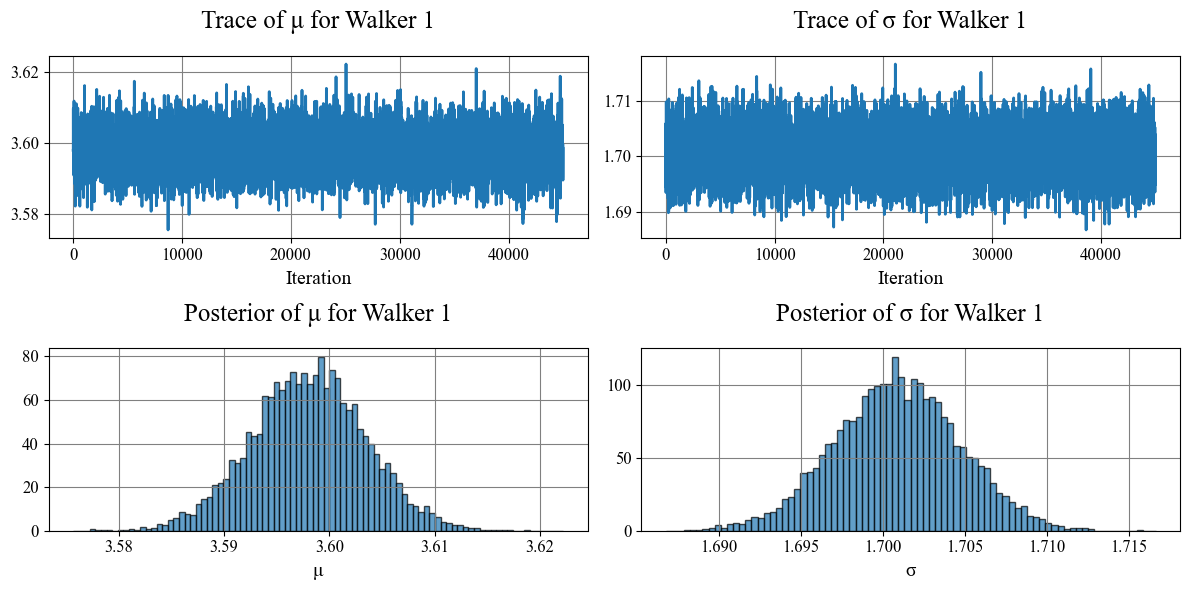

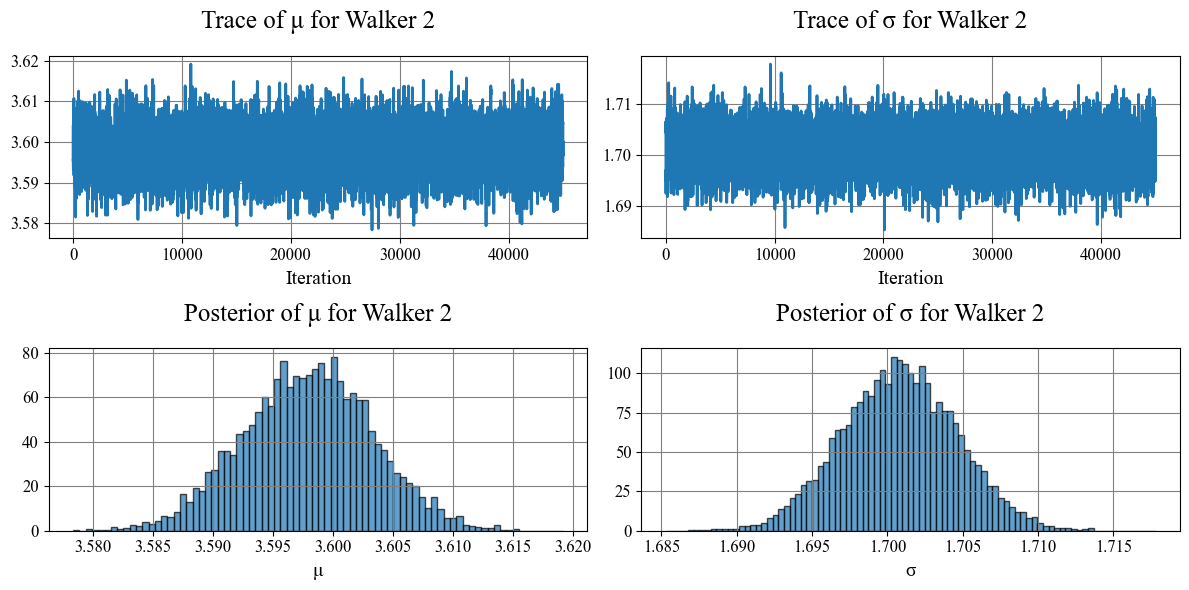

In [451]:
burn = 5000  # Burn-in period

for i in range(samples.shape[0]//2):
    plt.figure(figsize=(12, 6))
    
    # Trace plots
    plt.subplot(2, 2, 1)
    plt.plot(samples[i].T[0][burn:])
    plt.title(f"Trace of μ for Walker {i+1}")
    plt.xlabel("Iteration")
    
    plt.subplot(2, 2, 2)
    plt.plot(samples[i].T[1][burn:])
    plt.title(f"Trace of σ for Walker {i+1}")
    plt.xlabel("Iteration")

    # Histogram plots (posterior distribution)
    plt.subplot(2, 2, 3)
    plt.hist(samples[i].T[0][burn:], bins='scott', density=True, alpha=0.7, histtype='barstacked', edgecolor='black')
    plt.title(f"Posterior of μ for Walker {i+1}")
    plt.xlabel("μ")
    
    plt.subplot(2, 2, 4)
    plt.hist(samples[i].T[1][burn:], bins='scott', density=True, alpha=0.7, histtype='barstacked', edgecolor='black')
    plt.title(f"Posterior of σ for Walker {i+1}")
    plt.xlabel("σ")

    plt.tight_layout()
    plt.show()

In [455]:
import corner

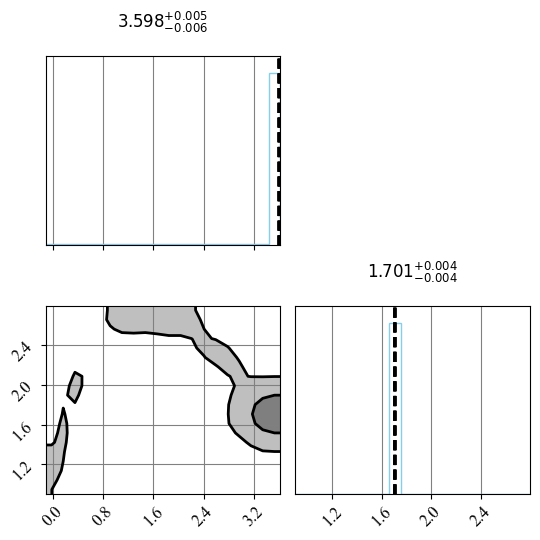

In [ ]:
fig = corner.corner(
    samples_flat,
    show_titles=True,          # Show median and credible intervals on top
    title_fmt=".3f",           # Format for title numbers
    quantiles=[0.16, 0.5, 0.84],  # Show 1-sigma credible intervals
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    hist_kwargs={"density": True, "color": "skyblue"},
    plot_datapoints=False,     # No scatter points in the plots, cleaner look
    fill_contours=True,        # Filled contour for density levels
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-4.5)),  # 1,2,3 sigma contour levels approx
    smooth=1.0                 # Smooth contours
)
